# RoPE: position as a turn

**The whole idea in one sentence:** turn the query by its position and the key by
its position; the dot product only sees the angle *between* them, so the shared
part of the turn cancels and only the distance survives.

Nothing is added to anything. That's the part that takes a while to believe, so
this notebook does it with quarter turns and numbers you can check in your head
before it does it with tensors.

It picks up where [sinusoidal.ipynb](sinusoidal.ipynb) left off. There, wheels made
"k slots back" *cheap to learn*. Here the same wheels make it *the only thing
attention can see* — by construction, not by training.

By the end you'll have:

- seen why a wheel needs **two** channels (you can't turn one number)
- scored *dog bites man* at positions 0, 1, 2 and again at 5, 6, 7, with every
  hand pointing somewhere different, and gotten the **same three scores**
- watched one wheel confuse distance 1 with distance 3, and a stack of wheels fix it
- printed the turn angles for the first ten positions, and watched the same
  "2 radians" reading walk down the stack as distance grows
- written RoPE the obvious way, then the way every library writes it
  (`rotate_half`), and traced that trick on `[1, 2, 3, 4]`
- mixed the two channel layouts on purpose — **nothing crashes, norms look
  healthy, and the scores quietly stop meaning distance**
- forgotten `pos_offset` at decode, and rotated the values too, and seen what each
  one silently breaks

In [1]:
import math

import numpy as np
import torch
import torch.nn.functional as F

torch.manual_seed(0)
np.set_printoptions(precision=2, suppress=True, linewidth=110)
torch.set_printoptions(precision=2, sci_mode=False, linewidth=110)

def show(t):
    # round for reading, and turn -0.00 into 0.00
    def clean(v):
        return [clean(u) for u in v] if isinstance(v, list) else round(v, 2) + 0.0
    return clean(t.tolist())

try:
    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.patches import Wedge
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib not installed - plot cells will print a note instead "
          "(uv sync --extra demo)")

---
## 1. A hand you can turn

Start with the smallest possible question: what does it mean to *turn* a vector?

Take one number, `x = 1`. What can you do to it? Scale it. Flip its sign. That's
all — there is no direction to point in with one coordinate, so there is nothing to
rotate. A hand on a clock needs an `x` and a `y`. **The smallest thing that can turn
is a pair.**

Turning the pair `[x, y]` by an angle is two multiplies and two adds:

In [2]:
def turn(pair, degrees):
    x, y = pair
    c, s = math.cos(math.radians(degrees)), math.sin(math.radians(degrees))
    return [round(x * c - y * s, 2) + 0.0, round(x * s + y * c, 2) + 0.0]

print("turn [1, 0] by quarter turns:")
for deg in (0, 90, 180, 270, 360):
    print(f"   {deg:>3} deg -> {turn([1, 0], deg)}")

turn [1, 0] by quarter turns:
     0 deg -> [1.0, 0.0]
    90 deg -> [0.0, 1.0]
   180 deg -> [-1.0, 0.0]
   270 deg -> [0.0, -1.0]
   360 deg -> [1.0, 0.0]


The `x` flows into the `y` and back. That mixing of two coordinates is what a
rotation *is*, and it's why a head of width 64 is not one vector being turned but
**32 pairs, each a hand on its own dial**.

A query is a hand. A key is a hand. RoPE's rule: turn each by *its position × a
speed*. Let's use a speed of 90° per token, so every turn is a quarter turn and you
can do the arithmetic without the computer.

---
## 2. One sentence, every number

*dog bites man*, a head of width 2, so each query and key is one hand. After the
projections, say the contents are:

In [3]:
key = {"dog": [1, 0], "bites": [0, 1], "man": [1, 0]}     # dog and man: same content, on purpose
query_man = [1, 0]
SPEED = 90                                                 # degrees per token

def dot(a, b):
    return round(a[0] * b[0] + a[1] * b[1], 2) + 0.0

def score_sentence(start):
    # 'man' (the last word) looks back at every word, with the sentence starting at `start`
    words = ["dog", "bites", "man"]
    q = turn(query_man, SPEED * (start + 2))
    print(f"sentence at positions {start}, {start + 1}, {start + 2}")
    print(f"   query man  at {start + 2}: turned {SPEED * (start + 2):>3} deg -> {q}")
    scores = []
    for i, w in enumerate(words):
        k = turn(key[w], SPEED * (start + i))
        scores.append(dot(q, k))
        print(f"   key {w:5} at {start + i}: turned {SPEED * (start + i):>3} deg -> {str(k):14}  man -> {w:5} = {scores[-1]:>5}")
    return scores

a = score_sentence(0)

sentence at positions 0, 1, 2
   query man  at 2: turned 180 deg -> [-1.0, 0.0]
   key dog   at 0: turned   0 deg -> [1.0, 0.0]      man -> dog   =  -1.0
   key bites at 1: turned  90 deg -> [-1.0, 0.0]     man -> bites =   1.0
   key man   at 2: turned 180 deg -> [-1.0, 0.0]     man -> man   =   1.0


Look at *dog* and *man*. They have **identical content**, `[1, 0]`. But *man* scores
itself `1` and scores *dog* `-1`. The only difference between them is distance —
0 versus 2 — and distance alone flipped the score. Position is doing its job, and
nothing was added to any vector.

Now put the same sentence later in a document, at positions 5, 6, 7. Bigger turns,
every hand pointing somewhere new:

In [4]:
b = score_sentence(5)
print(f"\nscores at 0,1,2: {a}")
print(f"scores at 5,6,7: {b}")

sentence at positions 5, 6, 7
   query man  at 7: turned 630 deg -> [0.0, -1.0]
   key dog   at 5: turned 450 deg -> [0.0, 1.0]      man -> dog   =  -1.0
   key bites at 6: turned 540 deg -> [0.0, -1.0]     man -> bites =   1.0
   key man   at 7: turned 630 deg -> [0.0, -1.0]     man -> man   =   1.0

scores at 0,1,2: [-1.0, 1.0, 1.0]
scores at 5,6,7: [-1.0, 1.0, 1.0]


**The same three scores.** Positions 5, 6 and 7 were fully present in those turned
vectors — 450°, 540°, 630° — and they vanished from every dot product.

The reason is one fact: a dot product is the two lengths times the cosine of the
angle *between* the hands. It has no idea where either hand points on its own.
Turning the query by 7 steps and the key by 5 is a shared turn of 5 plus a
difference of 2, and a shared turn cannot change the angle between two hands.

**That's the entire trick.** Turn the query by its position, turn the key by its
position, and only the gap reaches the score.

Here it is as a picture, with a gentler wheel (30° per token) so the wedge is easier
to see. Two placements of the same pair, two slots apart:

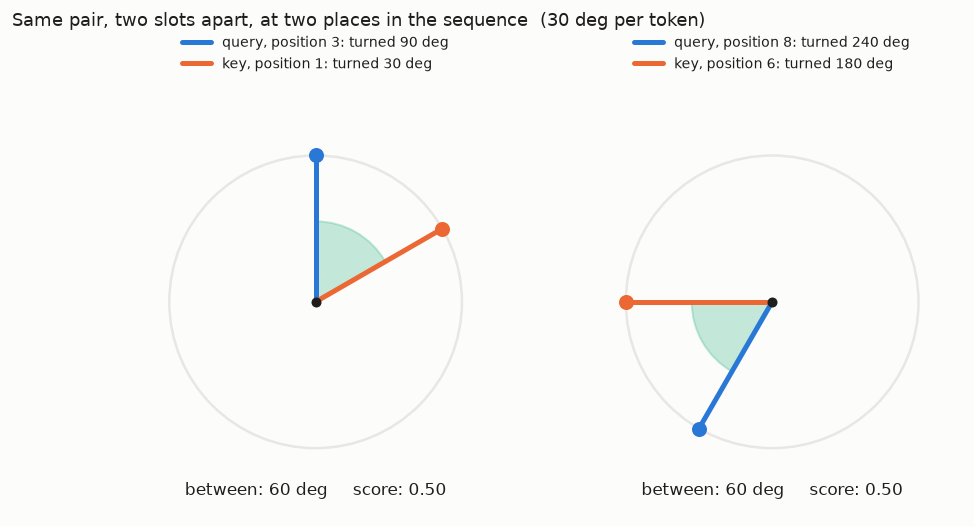

In [5]:
SURFACE, INK, INK2, GRID = "#fcfcfb", "#1f1e1d", "#6b6a63", "#e8e7e3"
Q_COL, K_COL, BETWEEN = "#2a78d6", "#eb6834", "#1baf7a"

def style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRID, lw=0.6)
    ax.tick_params(colors=INK2, labelsize=8)
    for s in ax.spines.values():
        s.set_visible(False)

def draw_dial(ax, m, n, speed):
    q_deg, k_deg = m * speed, n * speed
    between = ((q_deg - k_deg + 180) % 360) - 180
    ax.set_aspect("equal"); ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.45, 1.3); ax.axis("off")
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color=GRID, lw=1.5))
    lo, hi = (k_deg, k_deg + between) if between >= 0 else (k_deg + between, k_deg)
    ax.add_patch(Wedge((0, 0), 0.55, lo, hi, facecolor=BETWEEN, alpha=0.25, edgecolor=BETWEEN, lw=1.2))
    for deg, col, lab in ((q_deg, Q_COL, f"query, position {m}: turned {q_deg} deg"),
                          (k_deg, K_COL, f"key, position {n}: turned {k_deg} deg")):
        x, y = math.cos(math.radians(deg)), math.sin(math.radians(deg))
        ax.plot([0, x], [0, y], color=col, lw=3, solid_capstyle="round", label=lab)
        ax.plot([x], [y], "o", color=col, ms=8)
    ax.plot([0], [0], "o", color=INK, ms=5)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), fontsize=8.5, frameon=False, labelcolor=INK)
    ax.text(0, -1.32, f"between: {abs(between):.0f} deg     score: {math.cos(math.radians(between)):.2f}",
            ha="center", color=INK, fontsize=10)

if HAVE_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.6), dpi=120)
    fig.patch.set_facecolor(SURFACE)
    draw_dial(axes[0], 3, 1, 30)
    draw_dial(axes[1], 8, 6, 30)
    fig.suptitle("Same pair, two slots apart, at two places in the sequence  (30 deg per token)",
                 color=INK, fontsize=11, x=0.02, ha="left", y=1.04)
    plt.show()
else:
    print("(plot skipped)")

Every hand moved. The green wedge didn't.

### What people expect, and it doesn't happen

The natural guess is that RoPE *adds* a position vector, like the sinusoidal table
did. It doesn't add anything. The residual stream is untouched, the token vector
heading into the MLP is untouched, the values are untouched. Position exists only
for the instant a query meets a key, and it exists as a turn, not a nudge.

And "man at 7" does **not** carry a bigger or different position signal than "man
at 2" as far as the score is concerned. Look at the turned vectors and the absolute
position is plainly there. The score is the only place the model reads them, it
always reads two at once, and they cancel.

---
## 3. Why one wheel isn't enough

Stay with the 90° wheel and the same content in query and key. Score every distance:

In [6]:
print("distance   angle between   score")
for dist in range(0, 9):
    q = turn([1, 0], 90 * dist)
    print(f"   {dist}          {90 * dist % 360:>3} deg       {dot(q, [1, 0]):>5}")

distance   angle between   score
   0            0 deg         1.0
   1           90 deg         0.0
   2          180 deg        -1.0
   3          270 deg         0.0
   4            0 deg         1.0
   5           90 deg         0.0
   6          180 deg        -1.0
   7          270 deg         0.0
   8            0 deg         1.0


Distance 1 scores `0`. Distance 3 also scores `0`. Distance 4 looks exactly like
distance 0. One wheel cannot tell those apart, because a wave repeats — this is the
same worry as "won't the sinusoidal table eventually repeat?", and it has the same
answer.

**Many wheels, many speeds.** A head of width `d` is `d / 2` hands. Wheel 0 turns one
radian per token; each later wheel is slower than the one before by the same
constant factor; the last turns about `1 / base`. One line:

In [7]:
def wheel_speeds(head_dim, base=10000.0):
    return base ** (-torch.arange(0, head_dim, 2, dtype=torch.float32) / head_dim)   # radians per token

speeds = wheel_speeds(8, base=100.0)
print("wheel   rad/token   deg/token   laps every")
for i, s in enumerate(speeds.tolist()):
    print(f"  {i}      {s:.4f}     {math.degrees(s):>6.1f}     {2 * math.pi / s:>7.1f} tokens")
print(f"\neach wheel is {100 ** (2 / 8):.2f}x slower than the one before  (base ** (2 / head_dim))")

wheel   rad/token   deg/token   laps every
  0      1.0000       57.3         6.3 tokens
  1      0.3162       18.1        19.9 tokens
  2      0.1000        5.7        62.8 tokens
  3      0.0316        1.8       198.7 tokens

each wheel is 3.16x slower than the one before  (base ** (2 / head_dim))


The speeds are not learned. Pick a head width and a `base` and they're fixed.
(Which *channel pair* gets the fast wheel is pure convention — the formula counts
from `i = 0`, so wheel 0 is fastest. Reverse the order and the model trains the
same. It only matters once you load someone else's trained weights, which expect
their dials where they left them.)

### The first ten positions

Turn angle = position × speed. Read **down** a column: one dial ticking at a constant
rate, forever — nothing slows down as you move away from position 0. Read **across**
a row: the four angles that together *are* that position.

In [8]:
print("pos |" + "".join(f"   wheel {i}  " for i in range(4)))
print("----+" + "-" * 48)
for p in range(10):
    print(f"{p:>3} |" + "".join(f"{math.degrees(p * s):>9.1f}   " for s in speeds.tolist()))

pos |   wheel 0     wheel 1     wheel 2     wheel 3  
----+------------------------------------------------
  0 |      0.0         0.0         0.0         0.0   
  1 |     57.3        18.1         5.7         1.8   
  2 |    114.6        36.2        11.5         3.6   
  3 |    171.9        54.4        17.2         5.4   
  4 |    229.2        72.5        22.9         7.2   
  5 |    286.5        90.6        28.6         9.1   
  6 |    343.8       108.7        34.4        10.9   
  7 |    401.1       126.8        40.1        12.7   
  8 |    458.4       144.9        45.8        14.5   
  9 |    515.7       163.1        51.6        16.3   


Wheel 0 passes a full circle between positions 6 and 7, so by itself it can't tell
position 7 from somewhere near position 1. Wheel 1 reads 127° against 18°. The row
as a whole is unmistakable.

Now the part that matters for the score. Query at position 9, key at position 7:
the angle between them on wheel 0 is `515.7 − 401.1 = 114.6°` — **exactly the row
for position 2.** Distance 2, anywhere in the sequence, always produces the
position-2 row. That row is the fingerprint of *the distance*, for any pair.

### The same reading walks down the stack

Every dial spins at its own fixed speed. What changes with distance is how far each
one has moved *between the two hands* — distance × speed:

In [9]:
three = wheel_speeds(6, base=1000.0)          # speeds 1, 0.1, 0.01
print("distance |" + "".join(f"  wheel {i} ({s:.2f})" for i, s in enumerate(three.tolist())))
print("---------+" + "-" * 45)
for dist in (2, 20, 200):
    print(f"   {dist:>4}  |" + "".join(f"{dist * s:>12.2f} rad" for s in three.tolist()))

distance |  wheel 0 (1.00)  wheel 1 (0.10)  wheel 2 (0.01)
---------+---------------------------------------------
      2  |        2.00 rad        0.20 rad        0.02 rad
     20  |       20.00 rad        2.00 rad        0.20 rad
    200  |      200.00 rad       20.00 rad        2.00 rad


At distance 2, wheel 0 shows a clean, readable 2 radians; the others have barely
moved. At distance 20, wheel 0 has gone round three times — its reading is
meaningless — but wheel 1 now shows the same clean 2 radians. At distance 200 it's
wheel 2's turn.

**Near tokens are readable on the fast wheels, far tokens on the slow ones.** The
model learns which dial to trust at which range. Watch the false peaks disappear as
wheels are added — score against distance, same content in query and key:

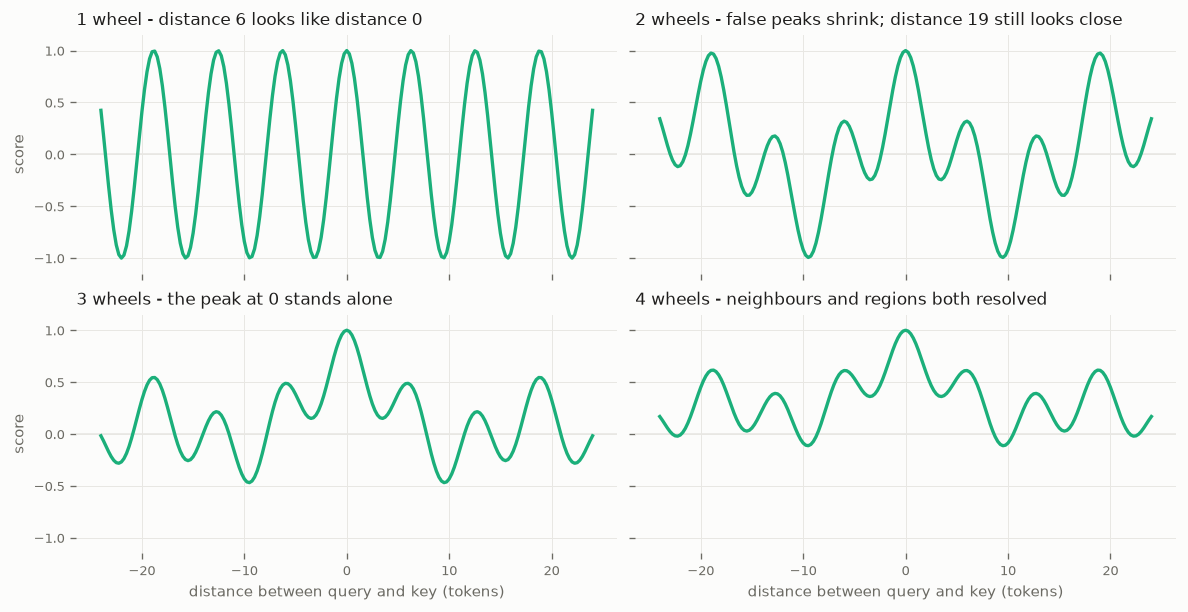

In [10]:
if HAVE_MPL:
    dist = np.arange(-24, 24.01, 0.25)
    sp = wheel_speeds(8, base=100.0).numpy()
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.2), dpi=120, sharex=True, sharey=True)
    fig.patch.set_facecolor(SURFACE)
    notes = {1: "distance 6 looks like distance 0",
             2: "false peaks shrink; distance 19 still looks close",
             3: "the peak at 0 stands alone",
             4: "neighbours and regions both resolved"}
    for w, ax in zip((1, 2, 3, 4), axes.flat):
        style(ax)
        score = np.mean([np.cos(dist * s) for s in sp[:w]], axis=0)
        ax.axhline(0, color=GRID, lw=1)
        ax.plot(dist, score, color=BETWEEN, lw=2)
        ax.set_title(f"{w} wheel{'s' if w > 1 else ''} - {notes[w]}", color=INK, fontsize=10, loc="left")
        ax.set_ylim(-1.15, 1.15)
    for ax in axes[1]:
        ax.set_xlabel("distance between query and key (tokens)", color=INK2, fontsize=9)
    for ax in axes[:, 0]:
        ax.set_ylabel("score", color=INK2, fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    print("(plot skipped)")

The cancellation in section 2 works for **any** speeds — 90°, 7°, random ones. Shift
invariance never depended on them. What the speeds decide is what the model can
*tell apart*: too fast and a wheel laps in a few tokens, too slow and it never
moves, all the same and you have one wheel copied 32 times. The spread is the point.

---
## 4. The general function

Do the turn for every hand, at every position, at once. First the obvious way:
cut the vector into its pairs, apply the two-line rotation from section 1, put the
pairs back.

"Cut into pairs" hides a choice — *which* two channels make a hand? There are two
conventions in the wild, and the choice gets a name here because section 6 is about
what happens when you forget it has one:

- **`interleaved`**: neighbours — channels `(0,1)`, `(2,3)`, ...
- **`half`**: across the middle — channels `(0, d/2)`, `(1, d/2 + 1)`, ...

In [11]:
def split_pairs(x, layout):
    if layout == "interleaved":
        return x[..., 0::2], x[..., 1::2]
    return x.chunk(2, dim=-1)

def join_pairs(a, b, layout):
    if layout == "interleaved":
        return torch.stack((a, b), dim=-1).flatten(-2)
    return torch.cat((a, b), dim=-1)

def rope(x, positions, speeds, layout="half"):
    angle = positions[:, None].float() * speeds[None, :]        # [S, n_wheels]: position x speed
    a, b = split_pairs(x, layout)                               # the two channels of every hand
    return join_pairs(a * angle.cos() - b * angle.sin(),        # the two lines from section 1
                      a * angle.sin() + b * angle.cos(), layout)

Check it against the hand trace. Width 2, one wheel, a quarter turn per token — the
turned keys for *dog bites man* at positions 0, 1, 2 should match section 2:

In [12]:
quarter = torch.tensor([math.pi / 2])
keys = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 0.0]])       # dog, bites, man
print("turned keys :", show(rope(keys, torch.arange(3), quarter)))
print("by hand     :", [turn(key[w], 90 * i) for i, w in enumerate(["dog", "bites", "man"])])

turned keys : [[1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0]]
by hand     : [[1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0]]


And the two properties that make it RoPE, on random queries and keys with a real
stack of wheels. Lengths are untouched (a turn never stretches anything), and the
whole score matrix is identical wherever the sequence sits:

In [13]:
S, D = 12, 16
sp = wheel_speeds(D)
q, k = torch.randn(S, D), torch.randn(S, D)

def scores_at(offset, q_layout="half", k_layout="half"):
    pos = torch.arange(S) + offset
    return rope(q, pos, sp, q_layout) @ rope(k, pos, sp, k_layout).T

rq = rope(q, torch.arange(S), sp)
print("lengths preserved:          ", torch.allclose(rq.norm(dim=-1), q.norm(dim=-1), atol=1e-5))
print("scores at offset 0 == 1000: ", torch.allclose(scores_at(0), scores_at(1000), atol=1e-3))

lengths preserved:           True
scores at offset 0 == 1000:  True


---
## 5. How it's traditionally written: `rotate_half`

Open any model's source and you won't find `split_pairs`. You'll find this, and it
looks like magic until you trace it:

```python
def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

out = x * cos + rotate_half(x) * sin
```

Trace it on `x = [1, 2, 3, 4]`. The `half` layout pairs channel 0 with 2 and channel
1 with 3, so the hands are `(1, 3)` and `(2, 4)`. Give wheel 0 an angle of 90° and
wheel 1 an angle of 180°.

Step one: **write each angle twice**, once for each channel of its pair.

In [14]:
def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

x = torch.tensor([1.0, 2.0, 3.0, 4.0])
angle = torch.tensor([math.pi / 2, math.pi])            # wheel 0: 90 deg, wheel 1: 180 deg
cos = torch.cat((angle.cos(), angle.cos()))
sin = torch.cat((angle.sin(), angle.sin()))

print("x                   =", show(x))
print("cos, doubled        =", show(cos))
print("sin, doubled        =", show(sin))
print("rotate_half(x)      =", show(rotate_half(x)), "  <- cut in the middle, negate the back half, swap")
print()
print("x * cos             =", show(x * cos))
print("rotate_half(x) * sin=", show(rotate_half(x) * sin))
print("sum                 =", show(x * cos + rotate_half(x) * sin))
print()
print("hand (1, 3) by  90 deg, from section 1:", turn([1, 3], 90), " -> channels 0 and 2")
print("hand (2, 4) by 180 deg, from section 1:", turn([2, 4], 180), " -> channels 1 and 3")

x                   = [1.0, 2.0, 3.0, 4.0]
cos, doubled        = [0.0, -1.0, 0.0, -1.0]
sin, doubled        = [1.0, 0.0, 1.0, 0.0]
rotate_half(x)      = [-3.0, -4.0, 1.0, 2.0]   <- cut in the middle, negate the back half, swap

x * cos             = [0.0, -2.0, 0.0, -4.0]
rotate_half(x) * sin= [-3.0, 0.0, 1.0, 0.0]
sum                 = [-3.0, -2.0, 1.0, -4.0]

hand (1, 3) by  90 deg, from section 1: [-3.0, 1.0]  -> channels 0 and 2
hand (2, 4) by 180 deg, from section 1: [-2.0, -4.0]  -> channels 1 and 3


Every hand got its own turn, and it took one multiply, one swap, one multiply and one
add over the whole vector.

Why it works: look at channel 0 of the sum. It's `a·cos + (−c)·sin` — the first line
of the rotation. Channel 2 is `c·cos + a·sin` — the second line. **`rotate_half`
puts each channel's partner, with the right sign, into the right slot** so that a
plain elementwise multiply lands the cross terms. That's all it is: a way to line
up partners.

The `interleaved` layout is the same trick with a different cut: partners are
neighbours, so you negate-and-swap *within* each adjacent pair, and you double the
angles by repeating each one next to itself instead of appending a copy of the list.

In [15]:
def rope_rotate_half(x, positions, speeds):
    angle = positions[:, None].float() * speeds[None, :]
    cos = torch.cat((angle.cos(), angle.cos()), dim=-1)          # [c0 c1 .. | c0 c1 ..]
    sin = torch.cat((angle.sin(), angle.sin()), dim=-1)
    return x * cos + rotate_half(x) * sin

def rotate_every_two(x):
    x1, x2 = x[..., 0::2], x[..., 1::2]
    return torch.stack((-x2, x1), dim=-1).flatten(-2)

def rope_interleaved(x, positions, speeds):
    angle = positions[:, None].float() * speeds[None, :]
    cos = angle.cos().repeat_interleave(2, dim=-1)               # [c0 c0 c1 c1 ..]
    sin = angle.sin().repeat_interleave(2, dim=-1)
    return x * cos + rotate_every_two(x) * sin

pos = torch.arange(S)
print("rotate_half      == obvious version (half):       ",
      torch.allclose(rope_rotate_half(q, pos, sp), rope(q, pos, sp, "half"), atol=1e-5))
print("rotate_every_two == obvious version (interleaved):",
      torch.allclose(rope_interleaved(q, pos, sp), rope(q, pos, sp, "interleaved"), atol=1e-5))

one = torch.tensor([[1.0, 2.0, 3.0, 4.0]])
two_wheels = torch.tensor([math.pi / 2, math.pi])
print("\n[1, 2, 3, 4], same angles, interleaved hands (1,2) and (3,4):",
      show(rope_interleaved(one, torch.tensor([1]), two_wheels)[0]))

rotate_half      == obvious version (half):        True
rotate_every_two == obvious version (interleaved): True

[1, 2, 3, 4], same angles, interleaved hands (1,2) and (3,4): [-2.0, 1.0, -3.0, -4.0]


Same input, same angles, a different answer — `[-3, -2, 1, -4]` against
`[-2, 1, -3, -4]` — because different channels were treated as partners. Hold that
thought.

You'll also meet a third spelling (Llama's reference code): view each pair as a
complex number and multiply by `e^{iθ}`. Multiplying by `e^{iθ}` *is* a turn by `θ`,
so it's section 1 in different notation:

In [16]:
def rope_complex(x, positions, speeds):
    angle = positions[:, None].float() * speeds[None, :]
    z = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2).contiguous())   # neighbours -> complex
    return torch.view_as_real(z * torch.polar(torch.ones_like(angle), angle)).flatten(-2)

print("complex form == interleaved:", torch.allclose(rope_complex(q, pos, sp), rope_interleaved(q, pos, sp), atol=1e-5))

complex form == interleaved: True


---
## 6. Break it on purpose

Three traps. None of them raises.

### Trap 1: mixed layouts

The query gets turned with one pairing and the key with the other. This happens for
real — a main attention path using one convention and an auxiliary module written
against another is the bug that hit DeepSeek's sparse-attention indexer.

Every health check you'd think to run passes:

In [17]:
pos = torch.arange(S)
rq_i, rk_h = rope(q, pos, sp, "interleaved"), rope(k, pos, sp, "half")

print("no exception raised:        True")
print("query lengths preserved:   ", torch.allclose(rq_i.norm(dim=-1), q.norm(dim=-1), atol=1e-5))
print("key lengths preserved:     ", torch.allclose(rk_h.norm(dim=-1), k.norm(dim=-1), atol=1e-5))
print("scores finite:             ", bool(torch.isfinite(rq_i @ rk_h.T).all()))

no exception raised:        True
query lengths preserved:    True
key lengths preserved:      True
scores finite:              True


Now the one check that matters — do the scores still depend only on distance?

In [18]:
for name, ql, kl in (("matched (half, half)", "half", "half"),
                     ("mixed   (interleaved, half)", "interleaved", "half")):
    drift = (scores_at(0, ql, kl) - scores_at(1000, ql, kl)).abs().max().item()
    print(f"{name:30} max change in score when the sequence moves 1000 tokens: {drift:.4f}")

matched (half, half)           max change in score when the sequence moves 1000 tokens: 0.0001
mixed   (interleaved, half)    max change in score when the sequence moves 1000 tokens: 15.2924


Matched: zero, to float precision. Mixed: the scores move by whole units. The query's
wheel 0 lives in channels `(0, 1)`; the key's wheel 0 lives in channels `(0, 8)`. The
dot product multiplies channel by channel, so it is comparing hands that were never
partners, and the shared turn no longer cancels.

A model trained this way **still trains** — it has other ways to reduce loss — it
just can't rely on its position signal, and quality quietly degrades. See it for
every pair of positions at once. Same content everywhere, so with working RoPE the
score can only depend on `m − n`, which draws as clean diagonals:

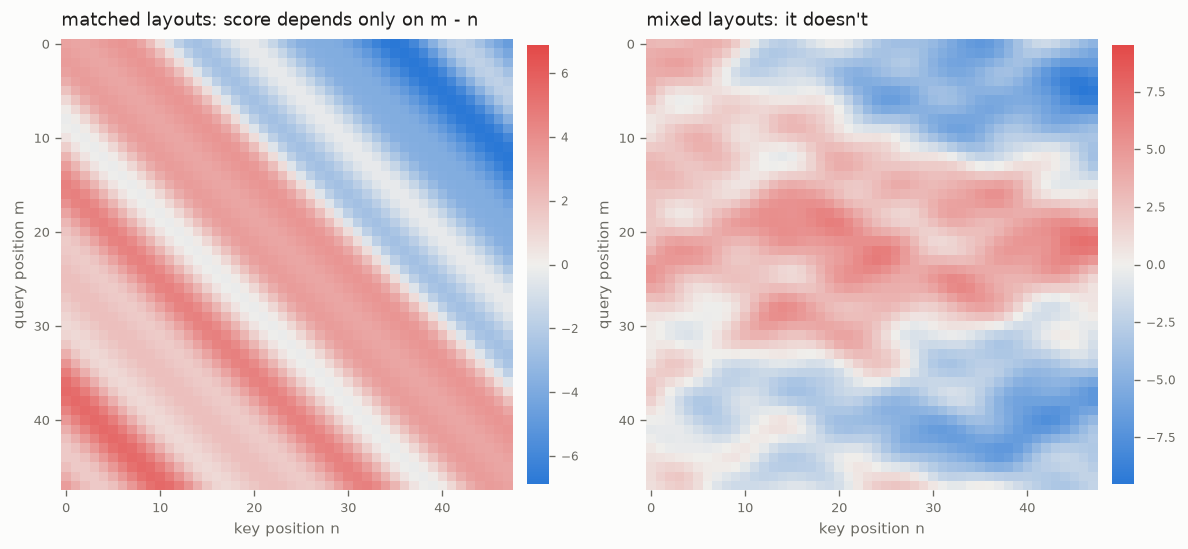

In [19]:
if HAVE_MPL:
    L, Dh = 48, 16
    spv = wheel_speeds(Dh, base=100.0)
    g = torch.Generator().manual_seed(3)
    q0, k0 = torch.randn(Dh, generator=g), torch.randn(Dh, generator=g)
    P = torch.arange(L)
    cmap = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), dpi=120)
    fig.patch.set_facecolor(SURFACE)
    for ax, (title, ql, kl) in zip(axes, (("matched layouts: score depends only on m - n", "half", "half"),
                                          ("mixed layouts: it doesn't", "interleaved", "half"))):
        sc = rope(q0.expand(L, Dh), P, spv, ql) @ rope(k0.expand(L, Dh), P, spv, kl).T
        lim = float(sc.abs().max())
        style(ax); ax.grid(False)
        im = ax.imshow(sc.numpy(), cmap=cmap, vmin=-lim, vmax=lim, interpolation="nearest")
        ax.set_title(title, color=INK, fontsize=10.5, loc="left", pad=8)
        ax.set_xlabel("key position n", color=INK2, fontsize=9)
        ax.set_ylabel("query position m", color=INK2, fontsize=9)
        cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
        cb.ax.tick_params(colors=INK2, labelsize=7); cb.outline.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print("(plot skipped)")

Left: every diagonal is one colour — one distance, one score, wherever you are.
Right: the same content at the same distance scores differently depending on where
the pair sits. It still looks *structured*, which is exactly why this survives into
real runs.

### Trap 2: forgetting `pos_offset` at decode

During generation the keys are rotated once, at their true positions, and cached.
Then a single new token arrives. It's alone in its tensor, so index 0 of that
tensor is *not* position 0 — it's position `S − 1`. Turn it by zero and it compares
itself against the cache as if it were the first token of the document:

In [20]:
pos = torch.arange(S)
cached_keys = rope(k, pos, sp)                                  # rotated at prefill, stored

full    = rope(q, pos, sp)[-1] @ cached_keys.T                  # the truth: whole sequence at once
correct = rope(q[-1:], torch.tensor([S - 1]), sp)[0] @ cached_keys.T
buggy   = rope(q[-1:], torch.tensor([0]), sp)[0] @ cached_keys.T   # "it's index 0 of this tensor"

print("scores, full sequence     :", show(full))
print("scores, decode offset=11  :", show(correct))
print("scores, decode offset=0   :", show(buggy))
print("\nwith the offset, decode == full:", torch.allclose(full, correct, atol=1e-4))

def top3(scores):
    w = scores.softmax(-1)
    return ",  ".join(f"token {int(i)}: {float(w[i]):.0%}" for i in w.topk(3).indices)

print("\nwhere the attention goes (top 3 tokens)")
print("   correct:", top3(full))
print("   buggy  :", top3(buggy))

scores, full sequence     : [0.9, -1.94, -2.31, -3.59, -2.57, -4.55, 1.0, -0.46, 2.24, 0.04, -0.2, -1.06]
scores, decode offset=11  : [0.9, -1.94, -2.31, -3.59, -2.57, -4.55, 1.0, -0.46, 2.24, 0.04, -0.2, -1.06]
scores, decode offset=0   : [2.9, -6.36, -3.93, 2.05, -0.99, -3.91, 0.76, -0.6, 6.73, -4.62, 4.82, -0.04]

with the offset, decode == full: True

where the attention goes (top 3 tokens)
   correct: token 8: 53%,  token 6: 15%,  token 0: 14%
   buggy  : token 8: 84%,  token 10: 13%,  token 0: 2%


Plausible numbers, a different attention pattern — the weights land on the wrong
tokens in the wrong proportions, and every one of them is a valid probability.
Nothing downstream can tell. This is why every hook in the repo's positional
interface takes a `pos_offset`, and why "cached generation matches cache-free
generation exactly" is the exit test for the generation step.

### Trap 3: rotating the values too

If turning `q` and `k` is good, why not `v`? Because values are never scored against
anything — nothing cancels their turn. It rides straight into the output as absolute
position:

In [21]:
v = torch.randn(S, D)

def attention(offset, rotate_values):
    pos = torch.arange(S) + offset
    w = (rope(q, pos, sp) @ rope(k, pos, sp).T / math.sqrt(D)).softmax(-1)
    return w @ (rope(v, pos, sp) if rotate_values else v)

for rv in (False, True):
    drift = (attention(0, rv) - attention(1000, rv)).abs().max().item()
    print(f"values rotated: {str(rv):5}   output changes by {drift:.4f} when the sequence moves 1000 tokens")

values rotated: False   output changes by 0.0000 when the sequence moves 1000 tokens
values rotated: True    output changes by 1.5134 when the sequence moves 1000 tokens


With values left alone, the layer's output is identical wherever the sequence sits —
the attention *weights* depend only on distance and the values carry only content.
Rotate the values and the output becomes a function of where you are in the
document. The position has leaked back in.

---
## 7. The packaged version

`litterbox.positional.RoPE` is section 4: a `_split`, the two-line rotation, a
`_join`. The rotation math is shared and **the layout is nothing but the choice of
split and join** — which is why it's a required argument with no default.

In [22]:
from litterbox.positional import RoPE

try:
    RoPE(head_dim=16, max_seq_len=128)
except TypeError as e:
    print("no layout, no RoPE:\n  ", e)

r = RoPE(head_dim=16, max_seq_len=128, layout="half")
Q, K = torch.randn(2, 4, S, 16), torch.randn(2, 4, S, 16)       # [batch, heads, seq, head_dim]
RQ, RK = r.rotate(Q, K)

print("\nsame numbers as ours:      ", torch.allclose(RQ, rope(Q, torch.arange(S), wheel_speeds(16), "half"), atol=1e-5))

one_q, one_k = r.rotate(Q[..., -1:, :], K[..., -1:, :], pos_offset=S - 1)
print("decode with pos_offset:    ", torch.allclose(one_q, RQ[..., -1:, :], atol=1e-5))

x = torch.randn(2, S, 64)
print("embed hook is the identity:", r.embed(x) is x, " <- RoPE never touches the residual stream")

try:
    r.rotate(Q, K, pos_offset=120)
except ValueError as e:
    print("\npast the table:\n  ", e)

no layout, no RoPE:
   RoPE.__init__() missing 1 required keyword-only argument: 'layout'

same numbers as ours:       True
decode with pos_offset:     True
embed hook is the identity: True  <- RoPE never touches the residual stream

past the table:
   positions 120..132 exceed the precomputed max_seq_len=128; extending context is yarn.py's job, not an implicit recompute


Three deliberate choices in there:

- **The angle tables are precomputed** in the constructor, `[max_seq_len, head_dim/2]`
  of `cos` and `sin`, and sliced by `pos_offset` at call time.
- **Reading past the table raises.** The formula could compute position 5,000 — it's
  just `sin` and `cos` — but those are turn angles the model has never seen on its
  slow wheels. Extending context is a decision (slow the wheels down so new
  positions sweep through *familiar* angles — YaRN's job), never an accident.
- **The turn happens in float32** even when activations are bf16. `sin` and `cos` of
  large angles lose too much in half precision, and this runs once per layer.

---
## What to remember

| what | why |
|---|---|
| the smallest thing that can turn is a pair | so a head of width `d` is `d / 2` hands, each on its own dial |
| turn `q` by `m`, turn `k` by `n` | the dot product sees only the angle between, so only `m − n` survives |
| nothing is added, `v` is never turned | position exists only where a query meets a key |
| speeds: `base ** (-2i / d)` | fixed, not learned; fast wheels read near distances, slow wheels read far ones |
| `rotate_half` lines up partners | one multiply, one swap, one multiply, one add |
| the layout is which channels are partners | mix them and nothing crashes; scores just stop meaning distance |
| `pos_offset` at decode | a lone token is not at position 0 |

Every trap here passes a norm check, a finiteness check and a shape check. The only
test that catches them is the property itself: **move the sequence, and the scores
must not change.** That's the first RoPE test in `tests/test_positional.py`.

---

## Exercises

1. **Find the collisions.** With one 90° wheel, list every distance up to 12 that
   scores the same as distance 1. Add a second wheel at 30° and list them again.
2. **Reverse the dials.** Flip `wheel_speeds` so the *slow* wheels come first. Show
   shift invariance still holds. Then explain what would go wrong if you loaded
   weights trained with the usual order.
3. **Read the distance.** Given only the four angles between the hands (one per
   wheel, each known only modulo 360°), recover the distance. Up to what distance
   is the answer unique for `head_dim = 8, base = 100`?
4. **Partial RoPE.** Turn only the first half of each head's channels and leave the
   rest alone. Verify shift invariance still holds. What can the un-turned channels
   express that the turned ones can't?
5. **Stretch the context.** Treat 64 as the training length. For positions 64–127,
   which wheels produce angles never seen in training? Now multiply every position
   by 0.5 before computing angles and check again. You've just done position
   interpolation — the idea `yarn.py` refines.
6. **Make it real.** Write the inside of an attention layer's forward: project to
   `q`, `k`, `v`, split into heads, call `q, k = pos.rotate(q, k, pos_offset)`, score,
   mask causally, mix the values. Pass `NoPE()` instead of `RoPE(...)` and confirm
   nothing else has to change. That's `full_attention.py`, the next file on the
   roadmap.